# <span style="color:#1E2D6B">PA-BI E-Commerce</span>  
## <span style="color:#E669B9">Machine Learning — Time Series & Forecasting</span>

---

### <span style="color:#1E2D6B">Objectif</span>

Cette section vise à **prévoir le chiffre d'affaires mensuel** à partir des données de ventes historiques du Data Warehouse `DW_E-Commerce`.  
Nous comparerons **au moins 2 modèles** de prévision conformément aux critères du projet.

---

### <span style="color:#1E2D6B">Modèles utilisés</span>
- <span style="color:#E669B9">SARIMA</span> — Modèle statistique classique avec saisonnalité  
- <span style="color:#E669B9">Prophet</span> — Modèle Facebook adapté aux séries business  
- <span style="color:#E669B9">XGBoost (supervisé)</span> — Approche ML avec features temporelles *(optionnel)*

---

### <span style="color:#1E2D6B">Résultats attendus</span>

- Identifier les **tendances et saisonnalités** des ventes  
- Produire des **prévisions fiables** sur les prochains mois  
- Aider à l'**optimisation des stocks** et des campagnes marketing

# 1. Installation des dépendances

In [ ]:
#pip install pyodbc sqlalchemy pandas matplotlib seaborn statsmodels pmdarima prophet xgboost scikit-learn

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   --------------------------- ---------- 524.3/711.9 kB 878.7 kB/s eta 0:00:01
   -------------------------------------- 711.9/711.9 kB 903.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 712.1 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/9.5 MB 712.1 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/9.5 MB 712.1 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.5 MB 542.5 kB/s eta 0:00:17
   --- --------------------------

# 2. Imports

In [84]:
import warnings
warnings.filterwarnings('ignore')

import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import create_engine, text
import urllib

# Statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# AutoARIMA
from pmdarima import auto_arima

# Prophet
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# XGBoost
import xgboost as xgb

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = {'train': '#1E2D6B', 'test': '#2ecc71', 'pred': '#E669B9', 'xgb': '#e67e22'}

print("✅ Imports OK")

✅ Imports OK


# 3. Connexion au Data Warehouse

In [85]:
# ── Paramètres de connexion ───────────────────────────────────
SERVER   = "KALLALA"
DATABASE = "DW_E-Commerce"

# ── Chaîne de connexion ───────────────────────────────────────
connection_string = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT DB_NAME() AS base_active"))
        print("✅ Connexion réussie ! Base active :", result.fetchone()[0])
except Exception as e:
    print("❌ Erreur de connexion :", e)

✅ Connexion réussie ! Base active : DW_E-Commerce


# 4. Construction de la Série Temporelle

On agrège `Fact_Ventes` × `DimDates` par **mois** pour obtenir le Chiffre d'Affaires mensuel.

| Colonne | Description |
|---|---|
| `Date` | Premier jour du mois |
| `CA_Mensuel` | Somme de `Montant_de_la_commande` |
| `Quantite_Mensuelle` | Somme des quantités vendues |
| `Nb_Commandes` | Nombre de transactions distinctes |

In [87]:
# Etape 1 : vérifier Fact_Ventes
df_check = pd.read_sql("SELECT TOP 5 * FROM Fact_Ventes", engine)
print(df_check)

   Vente_PK   Date_FK  Type_Vente_FK  Produit_FK  Categorie_FK  Client_FK  \
0     70945  20240930              2        8103           176       5890   
1     70946  20241030              2        8104           176       5891   
2     70947  20241108              2        8103           176       5890   
3     70948  20241113              2        8105           176       5892   
4     70949  20241113              2        8106           177       5892   

   Geographie_FK  Mode_Paiement_FK  Quantite  Montant_Livraison  \
0           2044                16         5                0.0   
1           2034                16       432                0.0   
2           2044                16         1                0.0   
3           2034                16       500                0.0   
4           2034                16       500                0.0   

   Montant_Remboursement  Montant_de_la_commande  Montant_Remise Code_Promo  \
0                    0.0                   160.0       

In [88]:
# Etape 2 : vérifier Dim_Date
df_check2 = pd.read_sql("SELECT TOP 5 * FROM DimDates", engine)
print(df_check2)

    Date_PK        Date      Jour_Moi_Annee   Annee      ID_Semestre  \
0  11111111  1111-11-11                None     NaN             None   
1  19500101  1950-01-01  1 - janvier - 1950  1950.0  1950 Semestre 1   
2  19500102  1950-01-02  2 - janvier - 1950  1950.0  1950 Semestre 1   
3  19500103  1950-01-03  3 - janvier - 1950  1950.0  1950 Semestre 1   
4  19500104  1950-01-04  4 - janvier - 1950  1950.0  1950 Semestre 1   

     Semestre      ID_Trimestre    Trimestre   ID_Mois  Mois Lib_Mois  Jour  \
0        None              None         None       NaN   NaN     None   NaN   
1  Semestre 1  1950 Trimestre 1  Trimestre 1  195001.0   1.0  janvier   1.0   
2  Semestre 1  1950 Trimestre 1  Trimestre 1  195001.0   1.0  janvier   2.0   
3  Semestre 1  1950 Trimestre 1  Trimestre 1  195001.0   1.0  janvier   3.0   
4  Semestre 1  1950 Trimestre 1  Trimestre 1  195001.0   1.0  janvier   4.0   

   Id_Lib_Jour  Lib_Jour  Semaine  JourDeAnnee        Jour_mois_lettre  
0          NaN     

In [89]:
# Etape 3 : vérifier la jointure
df_check3 = pd.read_sql("""
SELECT TOP 5 
    v.Date_FK, 
    d.Date_PK,
    d.Annee, 
    d.ID_Mois,
    v.Montant_de_la_commande
FROM Fact_Ventes v
JOIN DimDates d ON v.Date_FK = d.Date_PK
""", engine)
print(df_check3)

    Date_FK   Date_PK  Annee  ID_Mois  Montant_de_la_commande
0  20240930  20240930   2024   202409                   160.0
1  20241030  20241030   2024   202410                 26784.0
2  20241108  20241108   2024   202411                   192.0
3  20241113  20241113   2024   202411                 14500.0
4  20241113  20241113   2024   202411                  2500.0


In [90]:
query_regression_b2c = text("""
SELECT
    fv.Numero_Commande,   

    --  Cible (une seule valeur par commande)
    MAX(fv.Montant_de_la_commande) AS Montant_de_la_commande,

    --  Features agrégées
    SUM(fv.Quantite)           AS Quantite_totale,
    AVG(fv.Prix_Unité)         AS Prix_Unité_moyen,
    SUM(fv.Montant_Remise)     AS Montant_Remise,
    SUM(fv.Montant_Livraison)  AS Montant_Livraison,

    MAX(CASE WHEN fv.Code_Promo IS NOT NULL
         AND fv.Code_Promo != ''
         AND fv.Code_Promo != 'Aucun'
         THEN 1 ELSE 0 END) AS a_code_promo,

    --  Dimensions
    MAX(dc.Type_client)       AS Type_client,
    MAX(dc.Ville)             AS ville_client,
    MAX(dp.Prix)              AS prix_catalogue,
    CASE 
    WHEN MAX(CAST(dp.En_Promo AS INT)) = 1 THEN 1 
    ELSE 0 
END AS En_Promo,
    MAX(dp.Canal)             AS canal_produit,
    MAX(dcat.Categorie)       AS categorie,
    MAX(dtv.Type_Vente)       AS type_vente,
    MAX(dmp.Type_paiement)    AS type_paiement,

    --  Temps
    MAX(dd.Annee)             AS Annee,
    MAX(dd.Mois)              AS Mois,
    MAX(dd.Trimestre)         AS Trimestre,
    MAX(dd.Semestre)          AS Semestre,

    MAX(CASE WHEN dd.Mois IN (6,7,8,12)
         THEN 1 ELSE 0 END) AS est_saison_haute

FROM Fact_Ventes fv
JOIN Dim_Client dc   ON fv.Client_FK = dc.Client_PK
JOIN Dim_Produit dp  ON fv.Produit_FK = dp.Produit_PK
JOIN Dim_Categorie dcat ON fv.Categorie_FK = dcat.Categorie_PK
JOIN Dim_Type_Vente dtv ON fv.Type_Vente_FK = dtv.Type_Vente_PK
JOIN Dim_Mode_Paiement dmp ON fv.Mode_Paiement_FK = dmp.Mode_Paiement_PK
JOIN DimDates dd ON fv.Date_FK = dd.Date_PK

WHERE fv.Montant_de_la_commande > 0
AND dd.Date != '1111-11-11'
AND fv.Numero_Facture = 'Aucun'   -- Khater B2C kahaw

GROUP BY fv.Numero_Commande
ORDER BY MAX(dd.Date)
""")

# ── Chargement ───────────────────────────────────────────────
df_ts = pd.read_sql(query_regression_b2c, engine)

print(f"Dataframe Shape : {df_ts.shape}")

print(f"\nVerification :")
print(f"  orders number: {df_ts['Numero_Commande'].nunique():,}")
print(f"  Total lines     : {len(df_ts):,}")

# ── Key Verification ───────────────────────────────────────

duplicates = df_ts['Numero_Commande'].duplicated().sum()
print(f"\nDoublons Numero_Commande : {duplicates}")

# ── Target Statistics ───────────────────────────────────────
col_target = 'Montant_de_la_commande'

if col_target in df_ts.columns:
    print(f"\nTarget Statistics :")
    print(df_ts[col_target].describe().round(2))
else:
    raise ValueError(f"Colonne {col_target} introuvable")

# ── Feature Engineering  ─────────────────────────────

if 'Montant_Remise' in df_ts.columns and 'prix_catalogue' in df_ts.columns:
    df_ts['remise_pct'] = (
        df_ts['Montant_Remise'] /
        df_ts['prix_catalogue'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)
else:
    print("⚠️ remise_pct non calculée (colonnes manquantes)")

if 'Prix_Unité_moyen' in df_ts.columns and 'prix_catalogue' in df_ts.columns:
    df_ts['ratio_prix_catalogue'] = (
        df_ts['Prix_Unité_moyen'] /
        df_ts['prix_catalogue'].replace(0, np.nan)
    ).fillna(1).clip(0, 2)
else:
    print("⚠️ ratio_prix_catalogue not calculated")

# ── Data Verification ────────────────────────────────────
if 'Type_client' in df_ts.columns:
    print(f"\nType_client unique : {df_ts['Type_client'].unique()}")

print(f"\nMissing Values :")
missing = df_ts.isnull().sum()
print(missing[missing > 0])

# ──  final summary ─────────────────────────────────────────────
print(f"\n Final B2C DataFrame  :")
print(f"  Rows   : {df_ts.shape[0]:,}")
print(f"  Columns : {df_ts.shape[1]}")


Dataframe Shape : (440, 20)

Verification :
  orders number: 440
  Total lines     : 440

Doublons Numero_Commande : 0

Target Statistics :
count     440.00
mean      120.71
std       420.20
min        14.00
25%        68.75
50%        92.00
75%       104.00
max      6386.56
Name: Montant_de_la_commande, dtype: float64

Type_client unique : ['Particulier']

Missing Values :
ville_client    1
dtype: int64

 Final B2C DataFrame  :
  Rows   : 440
  Columns : 22


# Outliers

In [91]:
# ── Outliers Treatement (IQR) ─────────────────────────────

col = 'Montant_de_la_commande'

Q1 = df_ts[col].quantile(0.25)
Q3 = df_ts[col].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound : {lower_bound}")
print(f"Upper bound : {upper_bound}")

# Filtering
df_ts= df_ts[
    (df_ts[col] >= lower_bound) & 
    (df_ts[col] <= upper_bound)
]

# Verification
print("\nBefore treatement :", df_ts.shape)
print("After treatement :", df_ts.shape)
print("Count of Deleted lines :", df_ts.shape[0] - df_ts.shape[0])

Lower bound : 15.875
Upper bound : 156.875

Before treatement : (422, 22)
After treatement : (422, 22)
Count of Deleted lines : 0


# Construction De LA Serie Temporelle

In [92]:
import pandas as pd

# ── Créer une colonne Date mensuelle ───────────────────────
df_ts['Date'] = pd.to_datetime(
    df_ts['Annee'].astype(str) + '-' +
    df_ts['Mois'].astype(str).str.zfill(2) + '-01'
)

# ── Agrégation mensuelle ───────────────────────────────────
df_ts = df_ts.groupby('Date').agg({
    'Montant_de_la_commande': 'sum',
    'Quantite_totale': 'sum',
    'Numero_Commande': 'nunique',
    'Montant_Remise': 'sum',
    'Prix_Unité_moyen': 'mean'
}).rename(columns={
    'Montant_de_la_commande': 'CA_Mensuel',
    'Quantite_totale': 'Quantite_Mensuelle',
    'Numero_Commande': 'Nb_Commandes',
    'Montant_Remise': 'Remise_Totale',
    'Prix_Unité_moyen': 'Prix_Moyen_Unite'
})

# ── Trier par date ─────────────────────────────────────────
df_ts = df_ts.sort_index()

# ── Résumé ────────────────────────────────────────────────
print(f"Série temporelle construite : {len(df_ts)} mois")
print(f"Période : {df_ts.index.min().strftime('%b %Y')} → "
      f"{df_ts.index.max().strftime('%b %Y')}")

print("\nStatistiques CA_Mensuel :")
print(df_ts['CA_Mensuel'].describe().round(2))

print("\nAperçu :")
print(df_ts.head(6).to_string())

Série temporelle construite : 27 mois
Période : Jul 2023 → Jan 2026

Statistiques CA_Mensuel :
count      27.00
mean     1330.19
std      1681.30
min        18.00
25%        87.50
50%       215.00
75%      2221.40
max      6161.80
Name: CA_Mensuel, dtype: float64

Aperçu :
            CA_Mensuel  Quantite_Mensuelle  Nb_Commandes  Remise_Totale  Prix_Moyen_Unite
Date                                                                                     
2023-07-01      200.84                   3             3            0.0         66.946667
2023-08-01       42.02                   1             1            0.0         42.020000
2023-09-01       63.87                   4             1            0.0         15.970000
2023-12-01       49.00                   2             2            0.0         24.500000
2024-02-01       18.00                   3             1            0.0          6.000000
2024-03-01      123.00                   6             4            0.0         22.875000


In [167]:
# Vérification des valeurs manquantes et statistiques
print("=" * 50)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 50)
print(df_ts[['CA_Mensuel', 'Quantite_Mensuelle', 'Nb_Commandes']].describe().round(2))

print("\nValeurs manquantes :")
print(df_ts.isnull().sum())

# Série principale
serie = df_ts['CA_Mensuel'].copy()
serie.name = 'CA_Mensuel (TND)'

STATISTIQUES DESCRIPTIVES
       CA_Mensuel  Quantite_Mensuelle  Nb_Commandes
count       27.00               27.00         27.00
mean      1330.19               29.85         15.63
std       1681.30               34.67         18.56
min         18.00                1.00          1.00
25%         87.50                3.00          2.00
50%        215.00                6.00          4.00
75%       2221.40               51.50         24.00
max       6161.80              116.00         65.00

Valeurs manquantes :
CA_Mensuel            0
Quantite_Mensuelle    0
Nb_Commandes          0
Remise_Totale         0
Prix_Moyen_Unite      0
dtype: int64


# 5. Analyse Exploratoire (EDA Temporelle)

## 5.1 Visualisation de la série brute

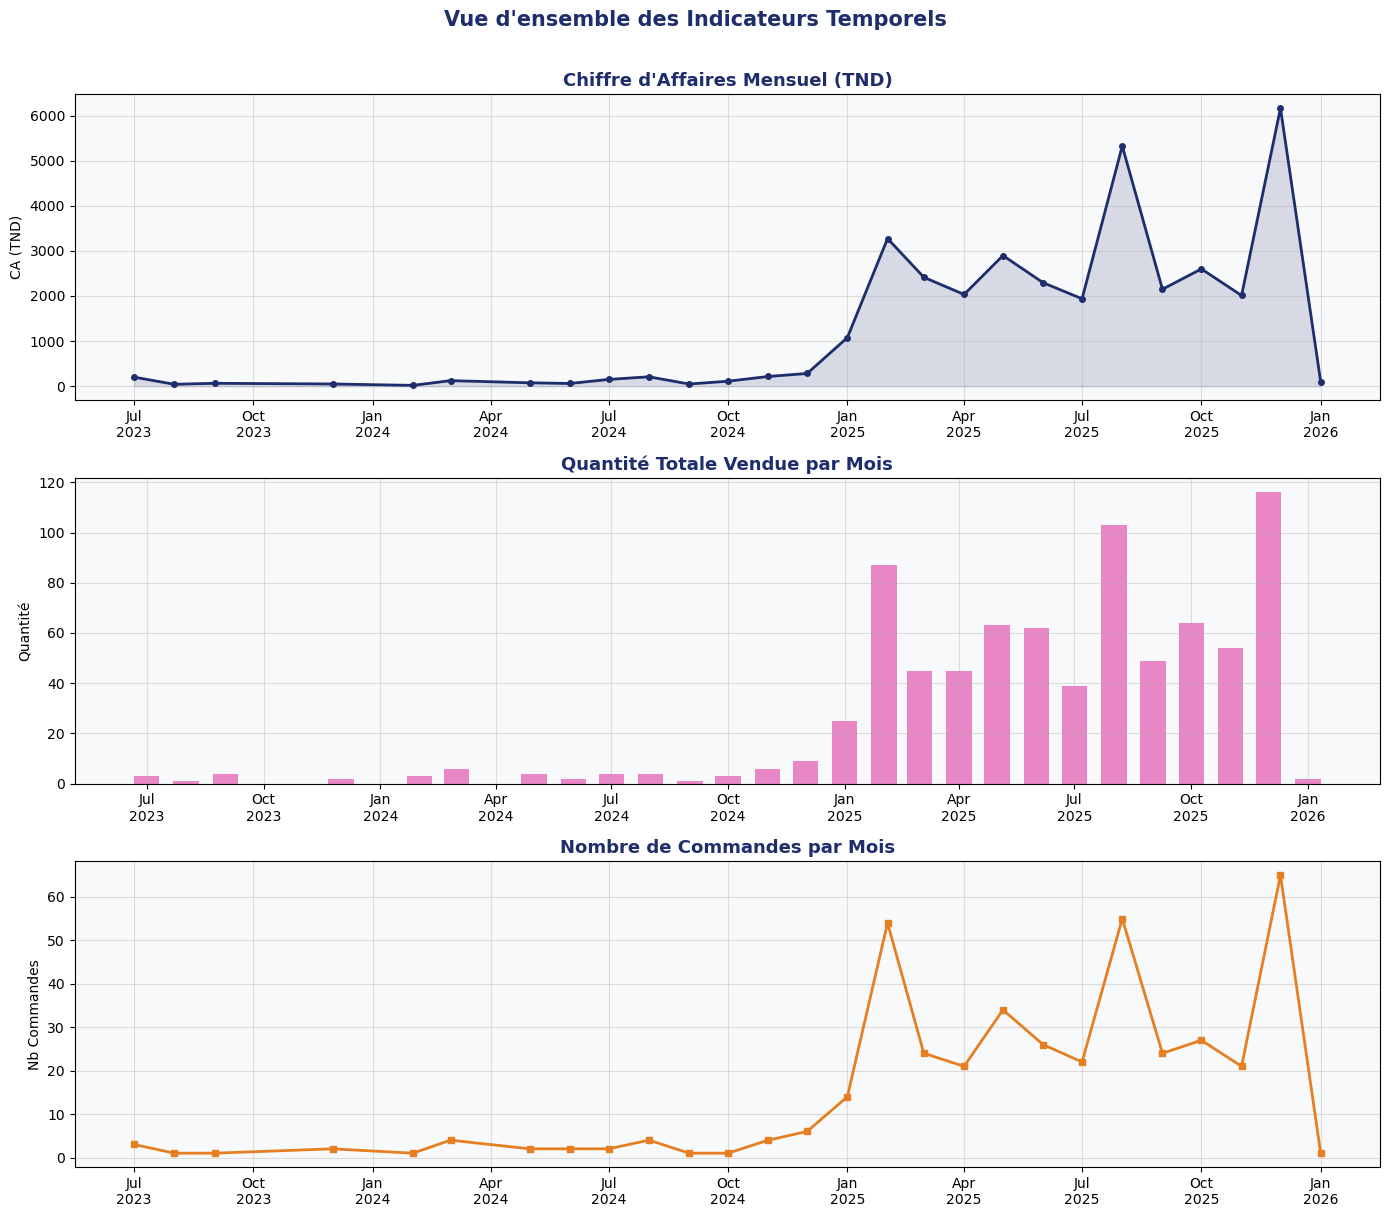

✅ Sauvegardé : ts_eda_overview.png


In [94]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# CA Mensuel
axes[0].plot(serie.index, serie.values, color=COLORS['train'], linewidth=2, marker='o', markersize=4)
axes[0].fill_between(serie.index, serie.values, alpha=0.15, color=COLORS['train'])
axes[0].set_title('Chiffre d\'Affaires Mensuel (TND)', fontsize=13, fontweight='bold', color='#1E2D6B')
axes[0].set_ylabel('CA (TND)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[0].grid(True, alpha=0.4)

# Quantité mensuelle
axes[1].bar(df_ts.index, df_ts['Quantite_Mensuelle'], color=COLORS['pred'], alpha=0.8, width=20)
axes[1].set_title('Quantité Totale Vendue par Mois', fontsize=13, fontweight='bold', color='#1E2D6B')
axes[1].set_ylabel('Quantité')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[1].grid(True, alpha=0.4)

# Nb commandes
axes[2].plot(df_ts.index, df_ts['Nb_Commandes'], color=COLORS['xgb'], linewidth=2, marker='s', markersize=4)
axes[2].set_title('Nombre de Commandes par Mois', fontsize=13, fontweight='bold', color='#1E2D6B')
axes[2].set_ylabel('Nb Commandes')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[2].grid(True, alpha=0.4)

plt.suptitle('Vue d\'ensemble des Indicateurs Temporels', fontsize=15, fontweight='bold', color='#1E2D6B', y=1.01)
plt.tight_layout()
plt.savefig('ts_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : ts_eda_overview.png")

## 5.2 Décomposition Saisonnière

La décomposition permet d'isoler :  
- **Tendance (Trend)** : évolution long terme du CA  
- **Saisonnalité (Seasonal)** : patterns récurrents (ex: pics été/décembre)  
- **Résidus (Residual)** : bruit aléatoire non expliqué

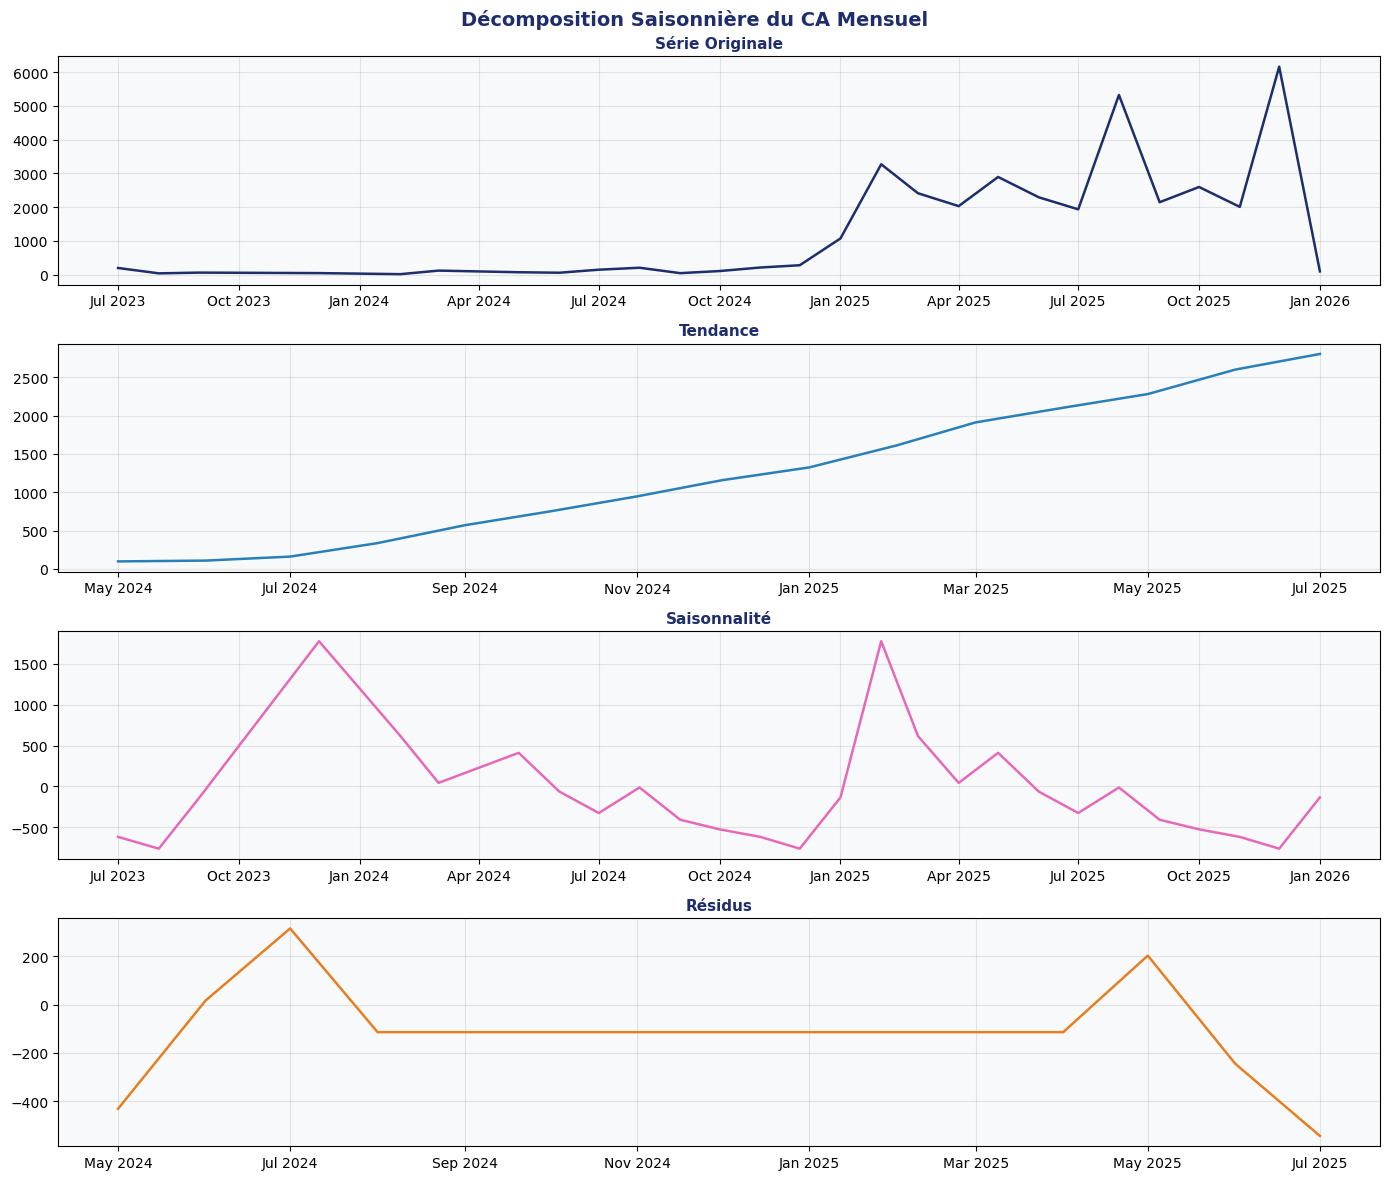

✅ Sauvegardé : ts_decomposition.png


In [95]:
# Décomposition additive (si la saisonnalité est constante)
# Utiliser 'multiplicative' si l'amplitude saisonnière croît avec la tendance
period = min(12, len(serie) // 2)

decomp = seasonal_decompose(serie.dropna(), model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
components = [
    (serie, 'Série Originale', COLORS['train']),
    (decomp.trend, 'Tendance', '#2980b9'),
    (decomp.seasonal, 'Saisonnalité', COLORS['pred']),
    (decomp.resid, 'Résidus', COLORS['xgb'])
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.8)
    ax.set_title(title, fontsize=11, fontweight='bold', color='#1E2D6B')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Décomposition Saisonnière du CA Mensuel', fontsize=14, fontweight='bold', color='#1E2D6B')
plt.tight_layout()
plt.savefig('ts_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : ts_decomposition.png")

## 5.3 Tests de Stationnarité

SARIMA requiert une série **stationnaire**. Deux tests complémentaires :

| Test | H₀ (hypothèse nulle) | Série stationnaire si |
|---|---|---|
| **ADF** | La série a une racine unitaire (non stationnaire) | p-value < 0.05 → rejeter H₀ |
| **KPSS** | La série est stationnaire | p-value > 0.05 → ne pas rejeter H₀ |

In [96]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

def test_stationarity(series, name='Série'):
    print(f"{'='*55}")
    print(f"  Tests de Stationnarité — {name}")
    print(f"{'='*55}")
    
    s = series.dropna()
    
    # Test ADF
    adf_result = adfuller(s, autolag='AIC')
    adf_p = adf_result[1]
    adf_stat = 'STATIONNAIRE ✅' if adf_p < 0.05 else 'NON STATIONNAIRE ⚠️'
    print(f"\n  ADF Test:")
    print(f"    Statistique : {adf_result[0]:.4f}")
    print(f"    p-value     : {adf_p:.4f}")
    print(f"    Conclusion  : {adf_stat}")
    
    # Test KPSS
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InterpolationWarning)
            kpss_result = kpss(s, regression='c', nlags='auto')
        kpss_p = kpss_result[1]
        kpss_stat = 'STATIONNAIRE ✅' if kpss_p > 0.05 else 'NON STATIONNAIRE ⚠️'
        print(f"\n  KPSS Test:")
        print(f"    Statistique : {kpss_result[0]:.4f}")
        print(f"    p-value     : {kpss_p:.4f}  (p-value réelle ≥ valeur affichée)")
        print(f"    Conclusion  : {kpss_stat}")
    except Exception as e:
        print(f"  KPSS : {e}")
    
    return adf_p < 0.05

is_stationary = test_stationarity(serie, 'CA Mensuel')
if not is_stationary:
    print("\n  → Différenciation d'ordre 1 recommandée (d=1 dans SARIMA)")
    serie_diff = serie.diff().dropna()
    print("\n  Test après différenciation :")
    test_stationarity(serie_diff, 'CA Mensuel (diff. 1)')

  Tests de Stationnarité — CA Mensuel

  ADF Test:
    Statistique : 0.9012
    p-value     : 0.9931
    Conclusion  : NON STATIONNAIRE ⚠️

  KPSS Test:
    Statistique : 0.6380
    p-value     : 0.0192  (p-value réelle ≥ valeur affichée)
    Conclusion  : NON STATIONNAIRE ⚠️

  → Différenciation d'ordre 1 recommandée (d=1 dans SARIMA)

  Test après différenciation :
  Tests de Stationnarité — CA Mensuel (diff. 1)

  ADF Test:
    Statistique : -1.1658
    p-value     : 0.6881
    Conclusion  : NON STATIONNAIRE ⚠️

  KPSS Test:
    Statistique : 0.2336
    p-value     : 0.1000  (p-value réelle ≥ valeur affichée)
    Conclusion  : STATIONNAIRE ✅


## 5.4 ACF / PACF — Identification des ordres AR et MA

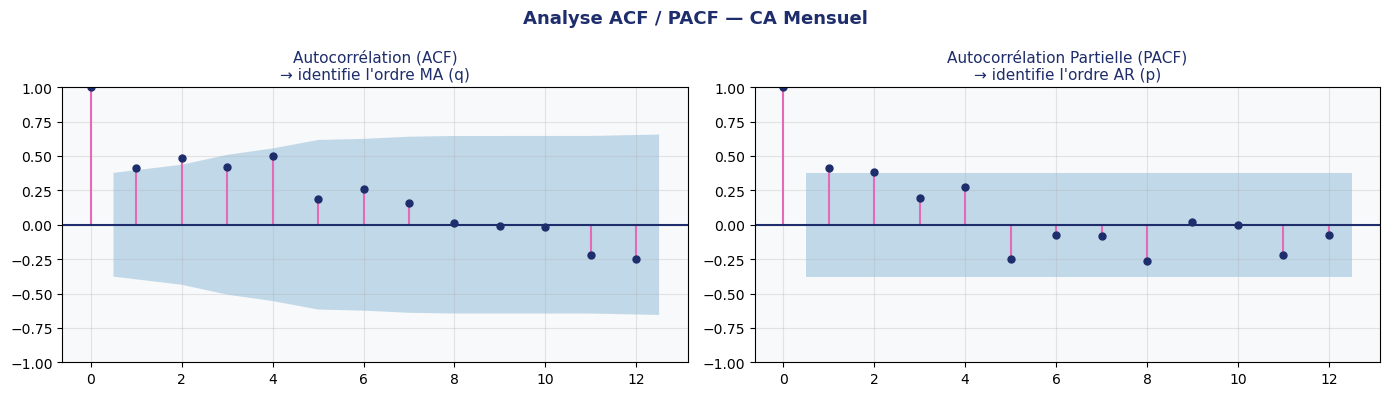

✅ Sauvegardé : ts_acf_pacf.png


In [97]:
s = serie.dropna()
n_lags = min(24, len(s) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(s, lags=n_lags, ax=axes[0], color=COLORS['train'], vlines_kwargs={'colors': COLORS['pred']})
axes[0].set_title('Autocorrélation (ACF)\n→ identifie l\'ordre MA (q)', fontsize=11, color='#1E2D6B')

plot_pacf(s, lags=n_lags, ax=axes[1], color=COLORS['train'], vlines_kwargs={'colors': COLORS['pred']})
axes[1].set_title('Autocorrélation Partielle (PACF)\n→ identifie l\'ordre AR (p)', fontsize=11, color='#1E2D6B')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Analyse ACF / PACF — CA Mensuel', fontsize=13, fontweight='bold', color='#1E2D6B')
plt.tight_layout()
plt.savefig('ts_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé : ts_acf_pacf.png")

# 6. Séparation Train / Test

On réserve les **3 derniers mois** comme ensemble de test pour évaluer les prévisions.

In [154]:
import pandas as pd
import numpy as np

df = df_ts.copy()

# ─────────────────────────────
# FEATURE ENGINEERING (XGBOOST ONLY)
# ─────────────────────────────
df['lag_1'] = df['CA_Mensuel'].shift(1)
df['lag_2'] = df['CA_Mensuel'].shift(2)
df['lag_3'] = df['CA_Mensuel'].shift(3)
df['rolling_mean_3'] = df['CA_Mensuel'].rolling(3).mean()

# Clean
df = df.dropna()

# ─────────────────────────────
# SPLIT GLOBAL (80/20)
# ─────────────────────────────
split = int(len(df) * 0.8)

train = df.iloc[:split]
test  = df.iloc[split:]

print("Shape train:", train.shape)
print("Shape test :", test.shape)

Shape train: (19, 9)
Shape test : (5, 9)


# 7. Modèle 1 — SARIMA

## 7.1 Compréhension du modèle

**SARIMA** *(Seasonal AutoRegressive Integrated Moving Average)* est une extension de ARIMA qui intègre la **composante saisonnière**.

**Paramètres :**

| Paramètre | Signification |
|---|---|
| `p` | Ordre AR — dépendance aux valeurs passées |
| `d` | Ordre de différenciation — pour stationnariser |
| `q` | Ordre MA — dépendance aux erreurs passées |
| `P, D, Q` | Mêmes paramètres au niveau saisonnier |
| `m` | Période saisonnière (12 pour mensuel/annuel) |

**Hypothèses :** Linéarité, résidus bruit blanc, série univariée  
**Limitations :** Sensible aux outliers, difficile à configurer manuellement  
**Justification :** Adapté aux données e-commerce avec **saisonnalité annuelle** (pics été/décembre identifiés dans la classification)

## 7.2 Sélection automatique des paramètres (auto_arima)

In [156]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

serie = df_ts['CA_Mensuel'].asfreq('MS').interpolate()

train_sarima = serie.iloc[:split]
test_sarima  = serie.iloc[split:]

In [157]:
model_auto = auto_arima(
    train_sarima,
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

print("Best order:", model_auto.order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=269.585, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=261.251, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=265.704, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=263.063, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=263.119, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=264.789, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=261.605, Time=0.07 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.385 seconds
Best order: (1, 0, 0)


## 7.3 Entraînement et Prévision

In [158]:
sarima_model = SARIMAX(
    train_sarima,
    order=model_auto.order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

pred_sarima = sarima_result.get_forecast(steps=len(test_sarima)).predicted_mean
pred_sarima.index = test_sarima.index

# 8. Modèle 2 — Prophet (Facebook / Meta)

## 8.1 Compréhension du modèle

**Prophet** est un modèle de prévision développé par Meta, conçu pour des **séries temporelles business** avec effets saisonniers et jours fériés.

**Fonctionnement :** Décompose la série en `y(t) = trend(t) + seasonality(t) + holidays(t) + noise`

| Composante | Modélisation |
|---|---|
| Tendance | Modèle linéaire ou logistique avec points de changement |
| Saisonnalité | Séries de Fourier |
| Jours fériés | Effets ponctuels personnalisables |

**Avantages :** Robuste aux valeurs manquantes, gère les outliers, facile à interpréter  
**Limitations :** Moins précis sur très courtes séries, ne modélise pas les dépendances AR  
**Justification :** Idéal pour les ventes e-commerce avec saisonnalité annuelle marquée et données partiellement manquantes

## 8.2 Préparation des données

In [159]:
from prophet import Prophet

prophet_df = df_ts.reset_index()[['Date', 'CA_Mensuel']]
prophet_df.columns = ['ds', 'y']

train_prophet = prophet_df.iloc[:split]
test_prophet  = prophet_df.iloc[split:]

## 8.3 Entraînement et Prévision

In [160]:
model_prophet = Prophet()
model_prophet.fit(train_prophet)

future = model_prophet.make_future_dataframe(
    periods=len(test_prophet),
    freq='MS'
)

forecast = model_prophet.predict(future)

pred_prophet = forecast['yhat'].iloc[-len(test_prophet):].values

11:34:31 - cmdstanpy - INFO - Chain [1] start processing
11:34:31 - cmdstanpy - INFO - Chain [1] done processing


# 9. Modèle 3 — XGBoost (Supervisé) *(Optionnel)*

## 9.1 Compréhension du modèle

**XGBoost** est un algorithme de gradient boosting. Pour les séries temporelles, on le transforme en problème supervisé via des **features de lag** (valeurs passées).

**Features créées :**
- `lag_1`, `lag_2`, `lag_3` : CA des 3 mois précédents
- `mois` : numéro du mois (saisonnalité)
- `trimestre` : numéro du trimestre
- `rolling_mean_3` : moyenne mobile sur 3 mois

**Avantages :** Capture les non-linéarités, robuste, feature importance interprétable  
**Limitations :** Ne projette pas au-delà des lags, besoin d'assez de données  
**Justification :** Complémentaire aux modèles statistiques, exploite les patterns non-linéaires des données e-commerce

## 9.2 Feature Engineering

In [161]:
X_train = train.drop(columns=['CA_Mensuel'])
y_train = train['CA_Mensuel']

X_test = test.drop(columns=['CA_Mensuel'])
y_test = test['CA_Mensuel']

## 9.3 Entraînement XGBoost

In [162]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

In [168]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" XGBOOST")
print("MAE :", mean_absolute_error(y_test, pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))
print("R²  :", r2_score(y_test, pred_xgb))

 XGBOOST
MAE : 231.86909606933597
RMSE: 383.93826134668376
R²  : 0.962178356575139


# 10. Évaluation & Comparaison des Modèles

## 10.1 Métriques

| Métrique | Formule | Interprétation |
|---|---|---|
| **MAE** | `mean(|réel - prédit|)` | Erreur moyenne absolue en TND |
| **RMSE** | `sqrt(mean((réel - prédit)²))` | Erreur quadratique, pénalise les grands écarts |
| **MAPE** | `mean(|réel - prédit| / réel) × 100` | Erreur en % — comparable entre séries |

In [164]:
def compute_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE (%)": np.mean(
            np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))
        ) * 100
    }

results = []

results.append(compute_metrics(y_test, pred_xgb, "XGBoost"))
results.append(compute_metrics(test_sarima, pred_sarima, "SARIMA"))
results.append(compute_metrics(test_prophet['y'].values, pred_prophet, "Prophet"))

df_results = pd.DataFrame(results).set_index("Model")
df_results = df_results.sort_values(by="RMSE")

print("📊 COMPARAISON DES MODÈLES")
print("=" * 40)
print(df_results)

📊 COMPARAISON DES MODÈLES
                  MAE           RMSE            R2      MAPE (%)
Model                                                           
XGBoost    231.869096     383.938261      0.962178     27.129645
Prophet   1327.932290    1951.200386     -0.125925    340.349773
SARIMA   96592.977528  170126.714630 -12398.333840  41373.698833


# 11. Visualisations

## 11.1 Forecast vs Réel — Comparaison des 3 modèles

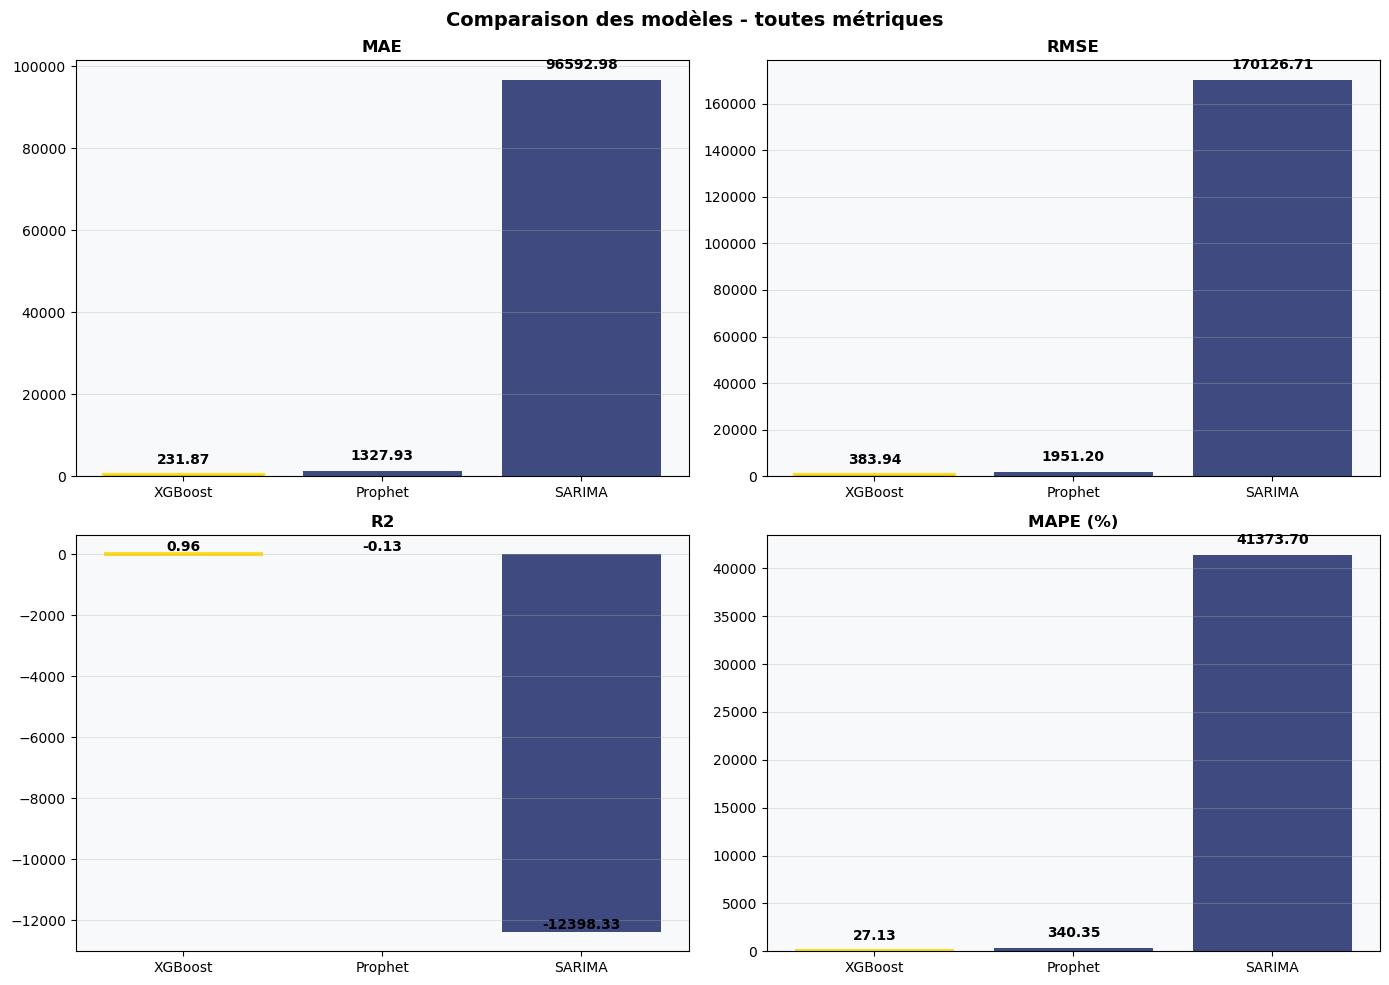

In [171]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ["MAE", "RMSE", "R2", "MAPE (%)"]
axes = axes.ravel()

colors = "#1E2D6B"

for ax, metric in zip(axes, metrics):

    vals = df_results[metric]

    bars = ax.bar(vals.index, vals.values, color=colors, alpha=0.85)

    ax.set_title(metric, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    # annotations
    max_val = vals.max()

    for bar, val in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_val * 0.02,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    # meilleur modèle (sauf R2 où max est meilleur)
    if metric == "R2":
        best_idx = vals.values.argmax()
    else:
        best_idx = vals.values.argmin()

    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(3)

plt.suptitle("Comparaison des modèles - toutes métriques", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 12. Meilleur modèle + prédiction

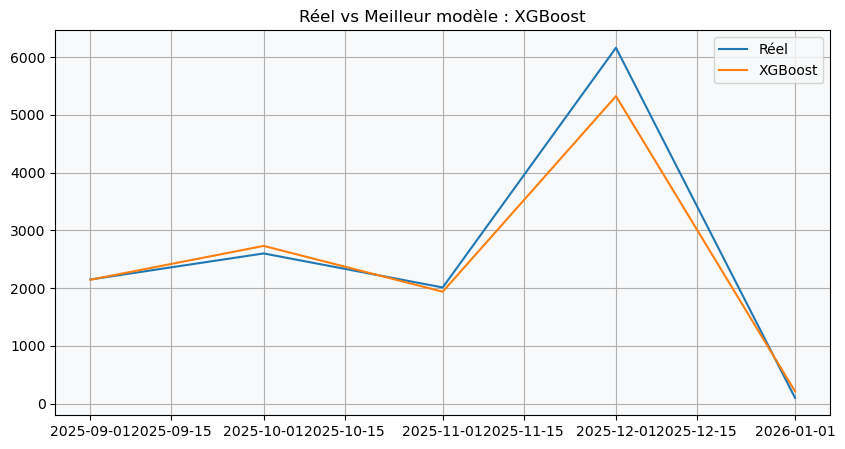

In [172]:
best_model = df_results.index[0]

plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Réel")

if best_model == "XGBoost":
    plt.plot(y_test.index, pred_xgb, label="XGBoost")
elif best_model == "SARIMA":
    plt.plot(test_sarima.index, pred_sarima, label="SARIMA")
elif best_model == "Prophet":
    plt.plot(test_prophet['ds'].iloc[-len(y_test):], pred_prophet, label="Prophet")

plt.title(f"Réel vs Meilleur modèle : {best_model}")
plt.legend()
plt.grid()
plt.show()